In [1]:
import ISLP as islp
import numpy as np
from IPython.core.pylabtools import figsize
import pandas as pd
import sklearn as sklearn
from matplotlib.pyplot import subplots
import seaborn as sns
import matplotlib.pyplot as plt

sklearn.set_config(transform_output="pandas")
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from marginaleffects import avg_slopes, slopes, plot_predictions, fit_sklearn, avg_comparisons, predictions, datagrid
from sklearn.naive_bayes import GaussianNB


In [2]:

test = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/meetups/meetup-5/data_set_ALL_AML_independent.csv")
train = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/meetups/meetup-5/data_set_ALL_AML_train.csv")
actual = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/meetups/meetup-5/actual.csv")

actual

y_train = actual.loc[0:37,"cancer"].reset_index(drop=True)
y_test = actual.loc[38:,"cancer"].reset_index(drop=True)



X_test = (
    test
    .drop(columns=[c for c in test.columns if "call" in c])
    .drop(columns=["Gene Description", "Gene Accession Number"])
    .pipe(lambda df: df.reindex(columns=sorted(df.columns, key=int)))
    .T
    .reset_index(drop=True)
)
X_train = (
    train
    .drop(columns=[c for c in train.columns if "call" in c])
    .drop(columns = ["Gene Description","Gene Accession Number"])
    .pipe(lambda df: df.reindex(columns=sorted(df.columns, key=int)))
    .T
    .apply(pd.to_numeric)
    .reset_index(drop=True)
)


pd.concat([y_train,X_train], axis=1).head(7).style





,cancer,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,10

In [3]:
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
print(classification_report(y_test, model_NB.predict(X_test)))




              precision    recall  f1-score   support

         ALL       0.95      0.90      0.92        20
         AML       0.87      0.93      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.91      0.91      0.91        34



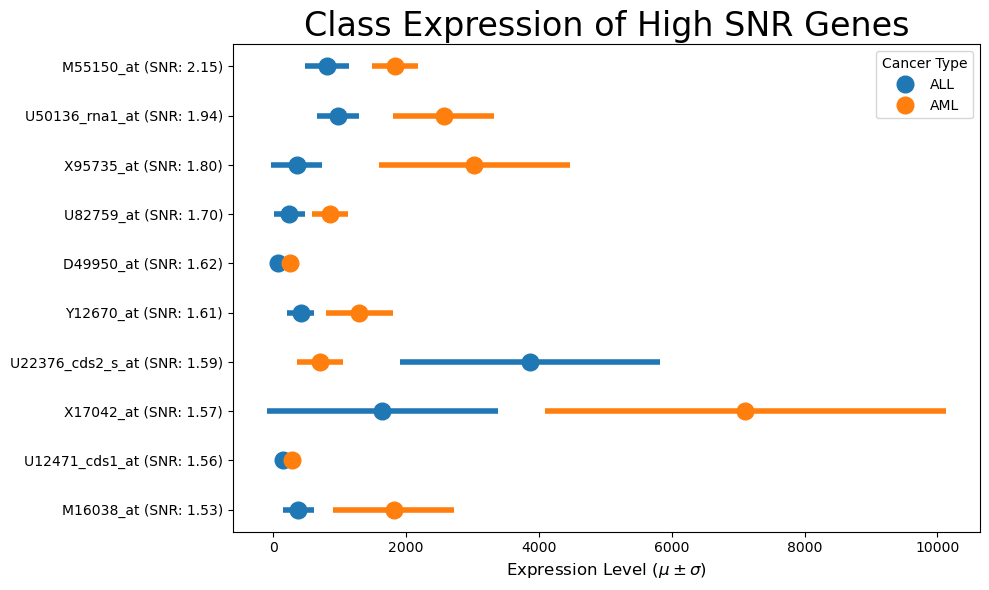

In [4]:

mu_0, mu_1 = model_NB.theta_[0], model_NB.theta_[1]
var_0, var_1 = model_NB.var_[0], model_NB.var_[1]
snr = np.abs(mu_1 - mu_0) / np.sqrt(var_1 + var_0)

gene_snr_df = (
  pd.DataFrame({
    'Gene_Accession': train['Gene Accession Number'],
    'Gene_Description': train['Gene Description'],
    'SNR': snr,
    'mu_0': mu_0,
    'mu_1': mu_1,
    'sigma_0': np.sqrt(var_0),
    'sigma_1': np.sqrt(var_1)
  })
  .sort_values(by='SNR', ascending=False)
  .head(10)
  .reset_index(drop=True)
)


df_plot = gene_snr_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_positions = np.arange(len(df_plot))




ax.errorbar(df_plot['mu_0'], y_positions, xerr=df_plot['sigma_0'], 
            fmt='o',  label='ALL', markersize=12,elinewidth=4)


ax.errorbar(df_plot['mu_1'], y_positions, xerr=df_plot['sigma_1'], 
            fmt='o',  label='AML', 
            elinewidth=4, markersize=12)

ylabels = [f"{gene} (SNR: {SNR:.2f})" for gene, SNR in zip(df_plot['Gene_Accession'], df_plot['SNR'])]

ax.set_yticks(y_positions)
ax.set_yticklabels(ylabels)
ax.invert_yaxis() 


ax.set_xlabel('Expression Level ($\mu \pm \sigma$)', fontsize=12)
ax.set_title('Class Expression of High SNR Genes', fontsize=24, )
ax.legend(loc='upper right', title="Cancer Type")


plt.tight_layout()
plt.show()



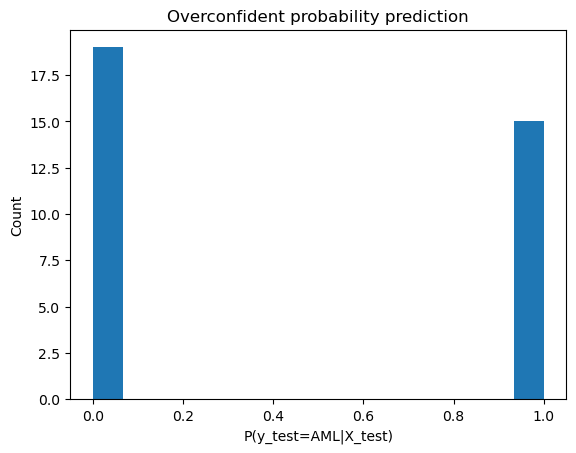

In [5]:
prob = model_NB.predict_proba(X_test)

plt.hist(prob[:, 1], bins=15)
plt.xlabel('P(y_test=AML|X_test)')
plt.ylabel('Count')
plt.title('Overconfident probability prediction');
